In [1]:
import pandas as pd
from pyprojroot import here
import geopandas as gpd

import matplotlib.pyplot as plt
import numpy as np

#### Spatial Analysis Data Processing

In [43]:
ROOT = here()

DATA_DIR = ROOT / "data"
OUTPUTS_DIR = ROOT / "outputs"

matrix_file_path = DATA_DIR / "lsoa_travel_times.parquet"
imd_path = DATA_DIR / "imd.parquet"
london_boundary_path = DATA_DIR / "LSOA_2011_London_gen_MHW.shp"

processed_data_path = DATA_DIR / "london_lsoa_education_accessibility.gpkg"

In [10]:
# read traveltimematrix parquet file
df_matrix = pd.read_parquet(matrix_file_path)

# read imd (deprivation) file
df_deprivation = pd.read_parquet(imd_path)

# read london lsoa boundary shp file
gdf_lsoa = gpd.read_file(london_boundary_path)

In [15]:
# merge data
merged_df = df_matrix.merge(
    df_deprivation, 
    left_on="lsoa_id", 
    right_on="LSOA code (2021)"
).drop(columns=["LSOA code (2021)"])

gdf = gdf_lsoa.merge(
    merged_df, 
    left_on="LSOA11CD",  
    right_on="lsoa_id"   
).drop(columns=["lsoa_id"])

In [45]:
# rename some super long column names
rename_dict = {
    # IMD Columns
    'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)': 'imd_decile',
    'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)': 'imd_rank',
    
    # IDACI Columns (Decile for filtering, Score for Cluster Analysis)
    'Income Deprivation Affecting Children Index (IDACI) Decile (where 1 is most deprived 10% of LSOAs)': 'idaci_decile',
    'Income Deprivation Affecting Children Index (IDACI) Score (rate)': 'idaci_score',
    'Income Deprivation Affecting Children Index (IDACI) Rank (where 1 is most deprived)': 'idaci_rank',
    
    # Population Columns
    'Total population: mid 2022': 'total_population',
    'Dependent Children aged 0-15: mid 2022': 'child_population'
}

In [46]:
# update gdf
gdf = gdf.rename(columns=rename_dict)

In [47]:
gdf.to_file(processed_data_path, driver='GPKG')

#### Quantifying Impact

> Statutory guidance in England, including London, suggests that a reasonable maximum journey time for secondary school children (aged 11-16) to school is 75 minutes each way. 

> Considering we are talking about _London_, I decided to set the bus travel time cap to be 40 min

In [48]:
# Defining Geographical Exclusion
# set threshold as Bus Time > 40min AND IDACI of Decile 1, 2, 3
TIME_THRESHOLD = 40
DEPRIVATION_THRESHOLD = 3

In [49]:
# creeate a Bool indicator
is_excluded = (gdf['tt_transit_nearest_outstanding'] > TIME_THRESHOLD) & \
              (gdf['idaci_decile'] <= DEPRIVATION_THRESHOLD)

In [50]:
gdf['exclusion_status'] = np.where(is_excluded, 'Excluded Deprived Area', 'Other')

In [51]:
# 1. How many lsoas are excluded?
excluded_lsoas_count = is_excluded.sum()
total_lsoas = len(gdf)
percentage_lsoas = (excluded_lsoas_count / total_lsoas) * 100

In [52]:
# 2. How many 0-15 aged children are excluded in the lsoa above?
affected_children = gdf.loc[is_excluded, 'child_population'].sum()
total_children = gdf['child_population'].sum()
percentage_children = (affected_children / total_children) * 100

In [53]:
print(f"Geographical Exclusion Analysis Results")
print(f"   (Thresholds: Transit > {TIME_THRESHOLD} mins, IDACI Decile <= {DEPRIVATION_THRESHOLD})")
print(f"-"*60)
print(f"Number of 'Double Disadvantage' LSOAs : {excluded_lsoas_count} ({percentage_lsoas:.1f}% of London)")
print(f"Total Affected Children (Aged 0-15)   : {affected_children:,.0f} ({percentage_children:.1f}% of London's children)")

Geographical Exclusion Analysis Results
   (Thresholds: Transit > 40 mins, IDACI Decile <= 3)
------------------------------------------------------------
Number of 'Double Disadvantage' LSOAs : 150 (3.2% of London)
Total Affected Children (Aged 0-15)   : 64,561 (4.1% of London's children)


##### Further discussion on "active travel" as an alternative

Since we know there are quite a large number of children have to take > 40min bus to school, we now analyse if cycling can be an alternative for these childre

> Debate: Could families of these excluded children afford bicycles? 

In [35]:
# 1. extract excluded childern
excluded_gdf = gdf[is_excluded].copy()
affected_children_total = excluded_gdf['child_population'].sum()

In [39]:
# 2. Calculate children who can reach an outstanding school by WALKING
# Based on the DfE statutory walking distance limit of 3 miles (approx. 60 mins)
can_walk_mask = excluded_gdf['tt_walk_nearest_outstanding'] <= 60
children_can_walk = excluded_gdf.loc[can_walk_mask, 'child_population'].sum()

In [40]:
# 3. Calculate children who can reach an outstanding school by CYCLING
# Aligning with the '15-Minute City' and active travel planning concepts (< 20 mins)
can_cycle_mask = excluded_gdf['tt_cycle_nearest_outstanding'] <= 20
children_can_cycle = excluded_gdf.loc[can_cycle_mask, 'child_population'].sum()

In [41]:
# 4. Calculate children facing ABSOLUTE transport exclusion
# Transit > 40 mins AND Walk > 60 mins AND Cycle > 20 mins
absolute_exclusion_mask = (~can_walk_mask) & (~can_cycle_mask)
absolute_excluded_children = excluded_gdf.loc[absolute_exclusion_mask, 'child_population'].sum()

In [42]:
print(f"Active Travel Mitigation Analysis")
print(f"   (Baseline: {affected_children_total:,.0f} children excluded by public transit)")
print(f"-"*70)
print(f"Accessible by Walking (< 60 mins): {children_can_walk:,.0f} ({(children_can_walk/affected_children_total)*100:.1f}% of excluded cohort)")
print(f"Accessible by Cycling (< 20 mins): {children_can_cycle:,.0f} ({(children_can_cycle/affected_children_total)*100:.1f}% of excluded cohort)")
print(f"Absolute Transport Deserts    : {absolute_excluded_children:,.0f} children (Unable to reach via ANY mode in reasonable time)")

Active Travel Mitigation Analysis
   (Baseline: 64,561 children excluded by public transit)
----------------------------------------------------------------------
Accessible by Walking (< 60 mins): 3,149 (4.9% of excluded cohort)
Accessible by Cycling (< 20 mins): 1,575 (2.4% of excluded cohort)
Absolute Transport Deserts    : 60,697 children (Unable to reach via ANY mode in reasonable time)


#### Discussion about the result:

- The analysis identifies a staggering baseline of 64,561 children residing in highly deprived LSOAs who are geographically excluded from 'Outstanding' secondary schools via public transit.

- While statutory guidelines suggest a 75-minute threshold, our data reveals a systemic infrastructure failure where over 60,000 disadvantaged children remain physically isolated from top-tier education regardless of mode.

- Contrary to the optimistic '15-minute city' narrative, active travel offers negligible mitigation, with only 2.4% of the excluded cohort able to reach these schools via cycling within 20 minutes.

- This evidence suggests that simply improving bus frequencies may be insufficient. Structural interventions are urgently required, such as strategic school placement or targeted transport subsidies for the most deprived outer-London boroughs.

#### Exclusion Mapping

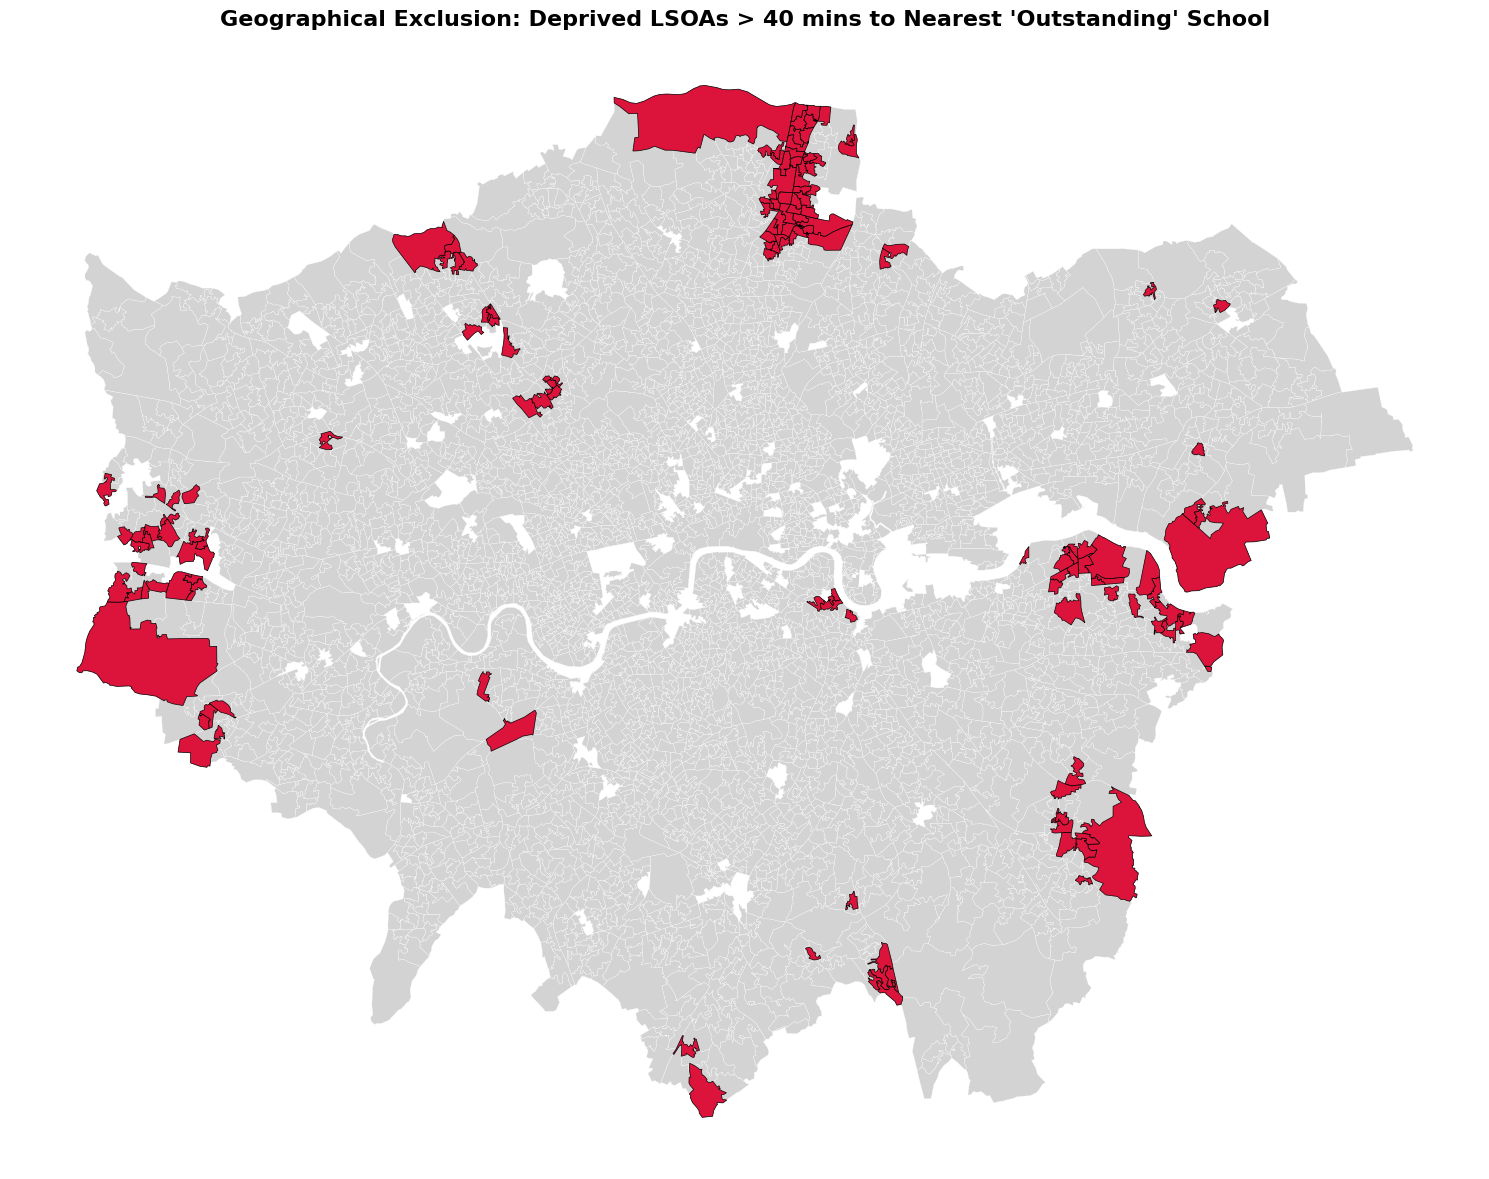

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# All LSOAs are lightgrey
gdf.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.2)

# Excluded areas are RED
gdf[gdf['exclusion_status'] == 'Excluded Deprived Area'].plot(
    ax=ax, color='crimson', edgecolor='black', linewidth=0.5, 
    label='Excluded Deprived Neighbourhoods'
)

ax.set_title("Geographical Exclusion: Deprived LSOAs > 40 mins to Nearest 'Outstanding' School", 
             fontsize=16, fontweight='bold', color='black')
ax.set_axis_off()


plt.tight_layout()

fig_path = OUTPUTS_DIR / "figures" / "geographical_exclusion_map.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()